[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/kasparvonbeelen/contracts/blob/main/3-1-influence_analysis.ipynb)

In [ ]:
!git clone https://github.com/kasparvonbeelen/contracts.git


In [ ]:
%cd contracts

In [ ]:
!pip install -q -e .

In [ ]:
from tools.utils import replace_minus_ones_with_prev
from pathlib import Path
import pandas as pd
import numpy as np
from tqdm.auto import tqdm
import seaborn as sns
import networkx as nx
import matplotlib.pyplot as plt
from itertools import combinations
from IPython.display import display
from ipywidgets import Dropdown, IntSlider, FloatSlider, VBox, HBox, Output
import plotly.graph_objects as go


In [ ]:
%cd /content

In [ ]:
!gdown 1OKtPh6Tzi1ess0DyQkOz9pIAVgSda5_X

In [ ]:
!unzip -q /content/tous.zip -d /content

In [ ]:
clause_type = "modification"  # arbitration, modification, 
data_path = "/content" # "./results"
embeddings_clause = np.loadtxt(f'{data_path}/tous/embedding_clauses_{clause_type}.tsv')
metadata_clause = pd.read_csv(f'{data_path}/tous/metadata_clauses_{clause_type}.tsv', sep='\t')

In [20]:

from tools.influence_analysis_helpers import (
    _prepare_nodes_and_embeddings,
    _build_time_influence_edges,
    _build_within_platform_update_edges,
    _build_coordination_edges,
)

# --- Parameters you can tune ---
SIM_THRESHOLD = 0.93                # cosine similarity threshold for influence edges
COORD_SIM_THRESHOLD = 0.93           # cosine similarity threshold for coordination edges
MAX_INFLUENCE_LAG_YEARS = 3         # only connect from up to N years in the past
K_CLOSEST_PER_PLATFORM = 2           # retained for coordination/local analyses (not used in first-occurrence cross-platform attribution)
COORD_TIME_WINDOW = 1                # |year_i - year_j| <= window for coordination
TOP_N_SENTENCES = 20                 # reporting/plotting cut-off

In [21]:
# Build temporal influence and coordination edges
nodes_df, emb_norm = _prepare_nodes_and_embeddings(metadata_clause, embeddings_clause)

# Cross-platform, first-occurrence attribution edges
influence_edges_df = _build_time_influence_edges(
    nodes=nodes_df,
    emb=emb_norm,
    sim_threshold=SIM_THRESHOLD,
    max_lag=MAX_INFLUENCE_LAG_YEARS,
    k_closest=K_CLOSEST_PER_PLATFORM,
)

# Within-platform carry-over edges (previous update -> next update)
within_platform_edges_df = _build_within_platform_update_edges(
    nodes=nodes_df,
    emb=emb_norm,
    sim_threshold=SIM_THRESHOLD,
    max_lag=MAX_INFLUENCE_LAG_YEARS,
)

# For influence scores we combine both edge types
influence_edges_for_scores_df = pd.concat([
    influence_edges_df,
    within_platform_edges_df,
], ignore_index=True)

coord_edges_df = _build_coordination_edges(
    nodes=nodes_df,
    emb=emb_norm,
    sim_threshold=COORD_SIM_THRESHOLD,
    time_window=COORD_TIME_WINDOW,
    k_closest=K_CLOSEST_PER_PLATFORM,
)

# Directed influence graph for scoring (cross-platform + within-platform carry-over)
G_infl = nx.from_pandas_edgelist(
    influence_edges_for_scores_df,
    source='source',
    target='target',
    edge_attr=['similarity', 'lag_years', 'source_platform', 'target_platform', 'source_year', 'target_year'],
    create_using=nx.DiGraph(),
)

for _, row in nodes_df.iterrows():
    n = int(row['node_id'])
    if n not in G_infl:
        G_infl.add_node(n)
    G_infl.nodes[n]['platform'] = row['platform']
    G_infl.nodes[n]['year'] = int(row['year'])
    G_infl.nodes[n]['sentence'] = row['sentence']

print(f'Nodes: {len(nodes_df):,}')
print(f'Cross-platform influence edges: {len(influence_edges_df):,}')
print(f'Within-platform carry-over edges: {len(within_platform_edges_df):,}')
print(f'Total edges for influence scoring: {len(influence_edges_for_scores_df):,}')
print(f'Coordination edges: {len(coord_edges_df):,}')
display(influence_edges_for_scores_df.head(5))

Building influence edges (first occurrence):   0%|          | 0/2223 [00:00<?, ?it/s]

Building coordination edges:   0%|          | 0/2223 [00:00<?, ?it/s]

Nodes: 2,223
Cross-platform influence edges: 1,012
Within-platform carry-over edges: 1,625
Total edges for influence scoring: 2,637
Coordination edges: 1,177


,source,target,similarity,lag_years,source_platform,target_platform,source_year,target_year,source_sentence,target_sentence
0,965,1,0.985215,3,ebay,uber,2012,2015,The arbitration will be conducted by the Ameri...,The arbitration will be administered by the Am...
1,1085,6,0.941693,1,grok,uber,2023,2024,ARBITRATION NOTICE AND CLASS ACTION WAIVER: EX...,"2) Class Action Waiver: Any and all disputes, ..."
2,1369,12,0.967608,1,zoom,uber,2023,2024,"If you are a California resident, the arbitrat...","For disputes arising in California, the arbitr..."
3,1846,13,0.930625,3,snapchat,uber,2021,2024,The arbitration will be conducted by a single ...,The arbitration shall be heard by one arbitrat...
4,869,15,0.938469,2,grindr,uber,2022,2024,You and Grindr therefore agree that before eit...,"The parties therefore agree that, before eithe..."


In [23]:
# Sentence-level and platform-level influence (recursive attribution to origins)
EDGE_BONUS = 0.25   # same bonus as before per outgoing edge
CHAIN_DECAY = 1.0   # set < 1.0 if you want weaker credit propagation over long chains

weighted_out = dict(G_infl.out_degree(weight='similarity'))
out_degree = dict(G_infl.out_degree())
in_degree = dict(G_infl.in_degree())

influence_scores = nodes_df[['node_id', 'platform', 'year', 'sentence']].copy()
influence_scores['weighted_out'] = influence_scores['node_id'].map(weighted_out).fillna(0.0)
influence_scores['out_degree'] = influence_scores['node_id'].map(out_degree).fillna(0).astype(int)
influence_scores['in_degree'] = influence_scores['node_id'].map(in_degree).fillna(0).astype(int)

# Direct score (old behavior): only immediate outgoing influence
influence_scores['direct_influence_score'] = (
    influence_scores['weighted_out'] + EDGE_BONUS * influence_scores['out_degree']
)

direct_map = influence_scores.set_index('node_id')['direct_influence_score'].to_dict()

# Recursive score: node gets its own direct score + propagated score from descendants
if nx.is_directed_acyclic_graph(G_infl):
    topo = list(nx.topological_sort(G_infl))
    recursive_map = {n: float(direct_map.get(n, 0.0)) for n in topo}

    for n in reversed(topo):
        downstream = sum(recursive_map[ch] for ch in G_infl.successors(n))
        recursive_map[n] = float(direct_map.get(n, 0.0)) + CHAIN_DECAY * downstream
else:
    # Fallback: if cycles exist, keep direct score to avoid unstable recursion
    print('Warning: influence graph is not a DAG; using direct influence score as fallback.')
    recursive_map = {n: float(direct_map.get(n, 0.0)) for n in G_infl.nodes}

influence_scores['recursive_influence_score'] = influence_scores['node_id'].map(recursive_map).fillna(0.0)

# Roots are "original" nodes (no incoming influence edges)
influence_scores['is_root'] = influence_scores['in_degree'].eq(0)
influence_scores['influence_score'] = np.where(
    influence_scores['is_root'],
    influence_scores['recursive_influence_score'],
    0.0,
)

top_sentences = (
    influence_scores
    .sort_values('influence_score', ascending=False)
    .head(TOP_N_SENTENCES)
    .copy()
)
top_sentences['sentence_short'] = top_sentences['sentence'].str.slice(0, 180)

print('Top influential root/original sentences (recursive score):')
display(
    top_sentences[[
        'platform',
        'year',
        'influence_score',
        'recursive_influence_score',
        'direct_influence_score',
        'weighted_out',
        'out_degree',
        'in_degree',
        'sentence_short',
    ]]
)

platform_influence = (
    influence_scores
    .groupby('platform', as_index=False)['influence_score']
    .sum()
    .sort_values('influence_score', ascending=False)
    .reset_index(drop=True)
)

print('Top influential platforms (root-attributed recursive score):')
display(platform_influence.head(20))

Top influential root/original sentences (recursive score):


,platform,year,influence_score,recursive_influence_score,direct_influence_score,weighted_out,out_degree,in_degree,sentence_short
165,uber,2011,25.440058,25.440058,25.440058,20.190058,21,0,"Unless you and Company otherwise agree, the ar..."
1215,paypal,2018,22.500000,22.500000,22.500000,18.000000,18,0,The terms include an agreement to resolve disp...
508,match,2022,19.306628,19.306628,19.306628,15.306628,16,0,If the Parties are unable to resolve the remai...
1049,ebay,1999,12.452164,12.452164,12.452164,9.952164,10,0,Any controversy or claim arising out of or rel...
89,uber,2021,11.011226,11.011226,11.011226,8.761226,9,0,"For disputes arising in California, the arbitr..."
92,uber,2021,10.822912,10.822912,10.822912,8.572912,9,0,"The parties therefore agree that, before eithe..."
1945,yahoo,2019,10.000000,10.000000,10.000000,8.000000,8,0,If for any reason a Dispute proceeds in court ...
1933,yahoo,2018,10.000000,10.000000,10.000000,8.000000,8,0,"We may, but are not obligated to, make a writt..."
1934,yahoo,2018,10.000000,10.000000,10.000000,8.000000,8,0,"To avoid any doubt or uncertainty, the parties..."
1931,yahoo,2018,9.909169,9.909169,9.909169,7.909169,8,0,If either you or Oath intends to arbitrate und...


Top influential platforms (root-attributed recursive score):


,platform,influence_score
0,uber,87.224869
1,yahoo,44.909169
2,paypal,30.000000
3,meetup,29.819774
4,bumble,29.716754
5,match,25.452626
6,gofundme,24.915939
7,ebay,19.910240
8,grindr,19.740434
9,snapchat,18.585587


In [ ]:
import plotly.io as pio

try:
    import google.colab  # type: ignore
    _IN_COLAB = True
except Exception:
    _IN_COLAB = False

pio.renderers.default = "colab" if _IN_COLAB else "notebook_connected"

root_candidates_df = (
    influence_scores[influence_scores['is_root']]
    .sort_values('influence_score', ascending=False)
    .copy()
)

if root_candidates_df.empty:
    print('No root nodes available for recursive chain visualization.')
else:
    root_options = [
        (
            f"{int(r.node_id)} | {r.platform} ({int(r.year)}) | score={r.influence_score:.2f}",
            int(r.node_id),
        )
        for r in root_candidates_df[['node_id', 'platform', 'year', 'influence_score']].itertuples(index=False)
    ]

    root_dropdown = Dropdown(
        options=root_options,
        value=root_options[0][1],
        description='Root node:',
        style={'description_width': '90px'},
        layout={'width': '700px'},
    )

    max_depth_slider = IntSlider(
        value=3,
        min=1,
        max=10,
        step=1,
        description='Max depth:',
        style={'description_width': '90px'},
        layout={'width': '300px'},
    )

    min_sim_slider = FloatSlider(
        value=0.88,
        min=0.50,
        max=0.99,
        step=0.01,
        description='Min sim:',
        style={'description_width': '90px'},
        layout={'width': '300px'},
    )

    out_chain = Output()
    HOVER_SENTENCE_CHARS = 220

    def _nodes_within_depth(graph, root, max_depth):
        depths = {root: 0}
        queue = [root]
        while queue:
            u = queue.pop(0)
            if depths[u] >= max_depth:
                continue
            for v in graph.successors(u):
                if v not in depths:
                    depths[v] = depths[u] + 1
                    queue.append(v)
        return depths

    def _plot_chain_plotly(H, layers, root_node, score_lookup, direct_lookup):
        edge_x = []
        edge_y = []
        edge_mid_x = []
        edge_mid_y = []
        edge_hover = []

        year_map = {}
        for n in H.nodes:
            if n in nodes_df.index:
                year_map[n] = int(nodes_df.loc[n, 'year'])
            else:
                year_map[n] = None

        valid_years = [y for y in year_map.values() if y is not None]
        use_year_layout = len(valid_years) > 0

        pos = {}
        if use_year_layout:
            nodes_by_year = {}
            for n in H.nodes:
                y = year_map[n]
                nodes_by_year.setdefault(y, []).append(n)

            for y in sorted(nodes_by_year.keys()):
                # Keep visual order stable: root depth first, then node id
                nodes_at_year = sorted(nodes_by_year[y], key=lambda n: (layers.get(n, 999), n))
                for i, n in enumerate(nodes_at_year):
                    pos[n] = (float(y), -i)
        else:
            level_nodes = {}
            for n, lv in layers.items():
                level_nodes.setdefault(lv, []).append(n)
            for lv, nodes_at_level in sorted(level_nodes.items()):
                nodes_at_level = sorted(nodes_at_level)
                for i, n in enumerate(nodes_at_level):
                    pos[n] = (lv, -i)

        for u, v, d in H.edges(data=True):
            x0, y0 = pos[u]
            x1, y1 = pos[v]
            edge_x += [x0, x1, None]
            edge_y += [y0, y1, None]
            edge_mid_x.append((x0 + x1) / 2.0)
            edge_mid_y.append((y0 + y1) / 2.0)
            edge_hover.append(
                f"{u} -> {v}<br>similarity: {d.get('similarity', 0.0):.3f}<br>lag_years: {d.get('lag_years', 'NA')}"
            )

        edge_trace = go.Scatter(
            x=edge_x,
            y=edge_y,
            line=dict(width=1.2, color='rgba(90,90,90,0.45)'),
            hoverinfo='none',
            mode='lines',
            showlegend=False,
        )

        edge_label_trace = go.Scatter(
            x=edge_mid_x,
            y=edge_mid_y,
            mode='markers',
            marker=dict(size=8, color='rgba(0,0,0,0)'),
            text=['' for _ in edge_mid_x],
            hovertemplate='%{customdata}<extra></extra>',
            customdata=edge_hover,
            showlegend=False,
        )

        node_meta = nodes_df.set_index('node_id')[['platform', 'year', 'sentence']]
        node_x = []
        node_y = []
        node_sizes = []
        node_colors = []
        node_platforms = []
        node_text = []
        node_hover = []

        for n in H.nodes:
            x, y = pos[n]
            node_x.append(x)
            node_y.append(y)

            rec_score = float(score_lookup.get(n, 0.0))
            dir_score = float(direct_lookup.get(n, 0.0))
            node_sizes.append(18 + 8 * np.sqrt(max(rec_score, 0.0)))

            if n in node_meta.index:
                platform = node_meta.loc[n, 'platform']
                year = int(node_meta.loc[n, 'year'])
                sentence = str(node_meta.loc[n, 'sentence'])
            else:
                platform = 'NA'
                year = -1
                sentence = ''

            node_platforms.append(platform)

            sentence_short = sentence[:HOVER_SENTENCE_CHARS] + ('...' if len(sentence) > HOVER_SENTENCE_CHARS else '')

            node_text.append(str(n))
            node_hover.append(
                "<br>".join([
                    f"node_id: {n}",
                    f"platform: {platform}",
                    f"year: {year}",
                    f"depth_from_root: {layers.get(n, -1)}",
                    f"recursive_score: {rec_score:.3f}",
                    f"direct_score: {dir_score:.3f}",
                    f"sentence: {sentence_short}"
                ])
            )
        platform_values = sorted(set(node_platforms))
        platform_palette = [
            '#1f77b4', '#ff7f0e', '#2ca02c', '#d62728', '#9467bd',
            '#8c564b', '#e377c2', '#7f7f7f', '#bcbd22', '#17becf',
        ]
        platform_color_map = {
            p: platform_palette[i % len(platform_palette)]
            for i, p in enumerate(platform_values)
        }
        node_colors = [platform_color_map[p] for p in node_platforms]

        node_trace = go.Scatter(
            x=node_x,
            y=node_y,
            mode='markers+text',
            text=node_text,
            textposition='top center',
            hovertemplate='%{customdata}<extra></extra>',
            customdata=node_hover,
            marker=dict(
                size=node_sizes,
                color=node_colors,
                line=dict(width=1, color='rgba(50,50,50,0.7)'),
            ),
            showlegend=False,
        )
        legend_traces = [
            go.Scatter(
                x=[None],
                y=[None],
                mode='markers',
                marker=dict(size=9, color=platform_color_map[p]),
                name=str(p),
                showlegend=True,
                hoverinfo='skip',
            )
            for p in platform_values
        ]

        root_score = float(score_lookup.get(root_node, 0.0))
        fig = go.Figure(data=[edge_trace, edge_label_trace, node_trace] + legend_traces)
        year_ticks = sorted({year_map[n] for n in H.nodes if year_map[n] is not None})

        fig.update_layout(
            title=(
                f"Recursive influence chain from root {root_node} | "
                f"nodes={H.number_of_nodes()} edges={H.number_of_edges()} | root score={root_score:.2f}"
            ),
            xaxis=dict(
                showgrid=True,
                zeroline=False,
                showticklabels=True,
                title='Year',
                tickmode='array' if use_year_layout else 'auto',
                tickvals=year_ticks if use_year_layout else None,
                ticktext=[str(y) for y in year_ticks] if use_year_layout else None,
            ),
            yaxis=dict(showgrid=False, zeroline=False, showticklabels=False),
            plot_bgcolor='white',
            hoverlabel=dict(align='left'),
            legend=dict(title='Platform'),
            margin=dict(l=10, r=10, t=60, b=10),
            height=max(500, 130 * len(set(layers.values()))),
        )
        return fig

    def render_recursive_chain(root_node, max_depth, min_sim):
        with out_chain:
            out_chain.clear_output(wait=True)

            if root_node not in G_infl:
                print('Selected root node is not present in the graph.')
                return

            depth_map = _nodes_within_depth(G_infl, root_node, max_depth)
            candidate_nodes = set(depth_map.keys())

            chain_edges = []
            for u, v, d in G_infl.edges(data=True):
                if u in candidate_nodes and v in candidate_nodes and d.get('similarity', 0.0) >= min_sim:
                    chain_edges.append((u, v, d))

            H = nx.DiGraph()
            for n in candidate_nodes:
                H.add_node(n)
            for u, v, d in chain_edges:
                H.add_edge(u, v, **d)

            isolated = [n for n in H.nodes if H.in_degree(n) == 0 and H.out_degree(n) == 0 and n != root_node]
            H.remove_nodes_from(isolated)

            if H.number_of_nodes() == 0 or (H.number_of_nodes() == 1 and H.number_of_edges() == 0):
                print('No downstream chain under current filters. Try increasing max depth or lowering min similarity.')
                return

            layers = {}
            for n in H.nodes:
                if n == root_node:
                    layers[n] = 0
                elif n in depth_map:
                    layers[n] = depth_map[n]
                else:
                    layers[n] = max_depth

            score_lookup = influence_scores.set_index('node_id')['recursive_influence_score'].to_dict()
            direct_lookup = influence_scores.set_index('node_id')['direct_influence_score'].to_dict()

            fig = _plot_chain_plotly(H, layers, root_node, score_lookup, direct_lookup)
            if _IN_COLAB:
                fig.show(renderer='colab')
            else:
                display(fig)

            rows = []
            for n in H.nodes:
                rows.append({
                    'node_id': int(n),
                    'depth_from_root': int(layers.get(n, -1)),
                    'recursive_influence_score': float(score_lookup.get(n, 0.0)),
                    'direct_influence_score': float(direct_lookup.get(n, 0.0)),
                    'out_degree_in_chain': int(H.out_degree(n)),
                    'in_degree_in_chain': int(H.in_degree(n)),
                })

            chain_table = pd.DataFrame(rows).sort_values(['depth_from_root', 'recursive_influence_score'], ascending=[True, False])
            display(chain_table.head(50))

    def _on_change(change):
        render_recursive_chain(root_dropdown.value, max_depth_slider.value, min_sim_slider.value)

    root_dropdown.observe(_on_change, names='value')
    max_depth_slider.observe(_on_change, names='value')
    min_sim_slider.observe(_on_change, names='value')

    controls = HBox([root_dropdown, max_depth_slider, min_sim_slider])
    display(VBox([controls, out_chain]))

    render_recursive_chain(root_dropdown.value, max_depth_slider.value, min_sim_slider.value)

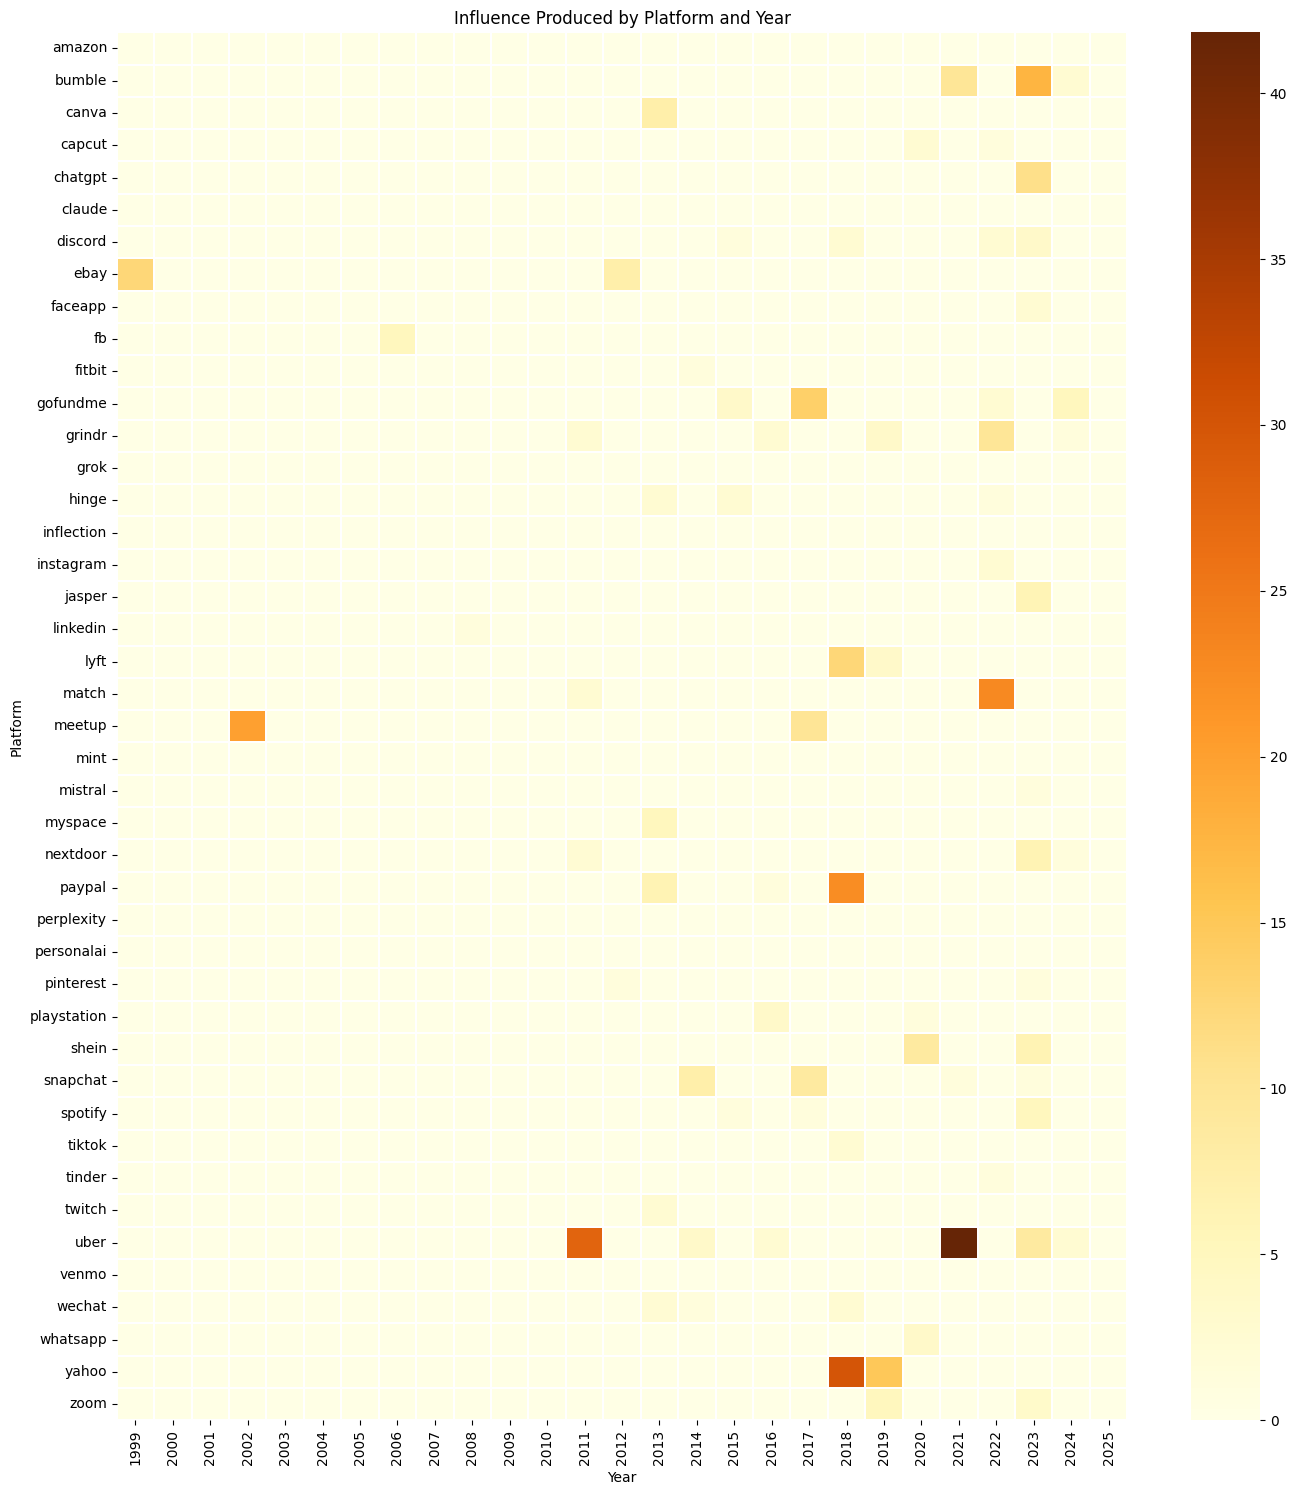

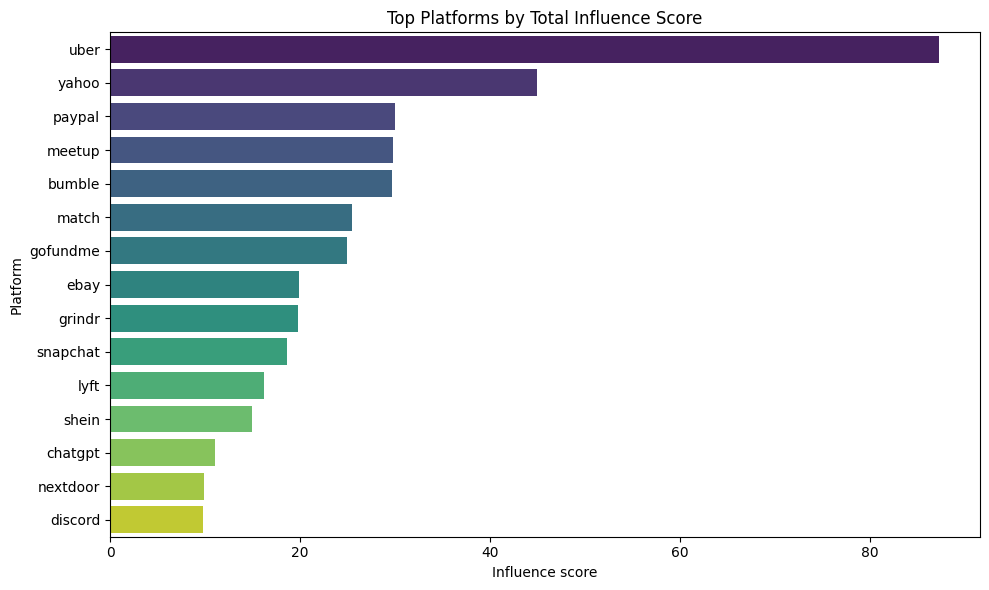

,year,platform,influence_score
0,1999,ebay,12.452164
1,2000,paypal,0.000000
2,2001,paypal,0.000000
3,2002,meetup,20.000000
4,2003,paypal,0.000000
5,2004,meetup,0.000000
6,2005,meetup,0.000000
7,2006,fb,4.933897
8,2007,fb,0.000000
9,2008,linkedin,1.250000


In [28]:
# Visualization A: who developed influential sentences, and when
platform_year_influence = (
    influence_scores
    .groupby(['platform', 'year'], as_index=False)['influence_score']
    .sum()
)

pivot_inf = platform_year_influence.pivot(index='platform', columns='year', values='influence_score').fillna(0)

plt.figure(figsize=(14, max(6, 0.35 * len(pivot_inf))))
sns.heatmap(pivot_inf, cmap='YlOrBr', linewidths=0.2)
plt.title('Influence Produced by Platform and Year')
plt.xlabel('Year')
plt.ylabel('Platform')
plt.tight_layout()
plt.show()

plt.figure(figsize=(10, 6))
sns.barplot(data=platform_influence.head(15), y='platform', x='influence_score', palette='viridis')
plt.title('Top Platforms by Total Influence Score')
plt.xlabel('Influence score')
plt.ylabel('Platform')
plt.tight_layout()
plt.show()

yearly_top = (
    platform_year_influence.sort_values(['year', 'influence_score'], ascending=[True, False])
    .groupby('year', as_index=False)
    .first()
)
display(yearly_top.head(20))

In [29]:
# Coordination summary: are platforms adopting similar clauses at the same time?
if coord_edges_df.empty:
    print('No coordination edges found at current threshold/window. Lower COORD_SIM_THRESHOLD or increase COORD_TIME_WINDOW.')
else:
    coord_edges_df = coord_edges_df.copy()
    coord_edges_df['platform_pair'] = coord_edges_df.apply(
        lambda r: ' | '.join(sorted([r['u_platform'], r['v_platform']])), axis=1
    )
    coord_edges_df['same_year'] = (coord_edges_df['u_year'] == coord_edges_df['v_year']).astype(int)
    coord_edges_df['abs_year_gap'] = (coord_edges_df['u_year'] - coord_edges_df['v_year']).abs()

    same_year_ratio = coord_edges_df['same_year'].mean()
    print(f'Share of coordinated edges in same year: {same_year_ratio:.3f}')

    coord_by_pair = (
        coord_edges_df
        .groupby('platform_pair', as_index=False)
        .agg(
            n_edges=('similarity', 'size'),
            mean_similarity=('similarity', 'mean'),
            same_year_share=('same_year', 'mean'),
        )
        .sort_values(['n_edges', 'mean_similarity'], ascending=False)
    )

    display(coord_by_pair.head(25))

    coord_by_year = (
        coord_edges_df
        .assign(mid_year=((coord_edges_df['u_year'] + coord_edges_df['v_year']) / 2).round().astype(int))
        .groupby('mid_year', as_index=False)
        .agg(
            n_edges=('similarity', 'size'),
            mean_similarity=('similarity', 'mean'),
            same_year_share=('same_year', 'mean'),
        )
        .sort_values('mid_year')
    )

    display(coord_by_year.head(30))

Share of coordinated edges in same year: 0.670


,platform_pair,n_edges,mean_similarity,same_year_share
136,paypal | venmo,90,0.998860,0.911111
37,claude | yahoo,37,0.951795,0.351351
75,fitbit | yahoo,36,0.945054,0.666667
56,ebay | paypal,33,0.994170,0.878788
54,ebay | mint,33,0.933598,0.545455
0,amazon | ebay,32,0.989835,0.531250
141,personalai | yahoo,32,0.954126,0.625000
123,mint | paypal,31,0.934969,0.677419
147,shein | yahoo,27,0.934799,0.703704
4,amazon | paypal,26,0.987779,0.346154


,mid_year,n_edges,mean_similarity,same_year_share
0,2000,2,0.992104,0.000000
1,2008,2,0.993490,0.500000
2,2010,7,0.995517,0.142857
3,2011,7,0.985941,1.000000
4,2012,43,0.980850,0.232558
5,2013,18,0.977413,1.000000
6,2014,45,0.959709,0.466667
7,2015,44,0.959894,1.000000
8,2016,124,0.962595,0.524194
9,2017,43,0.967771,1.000000


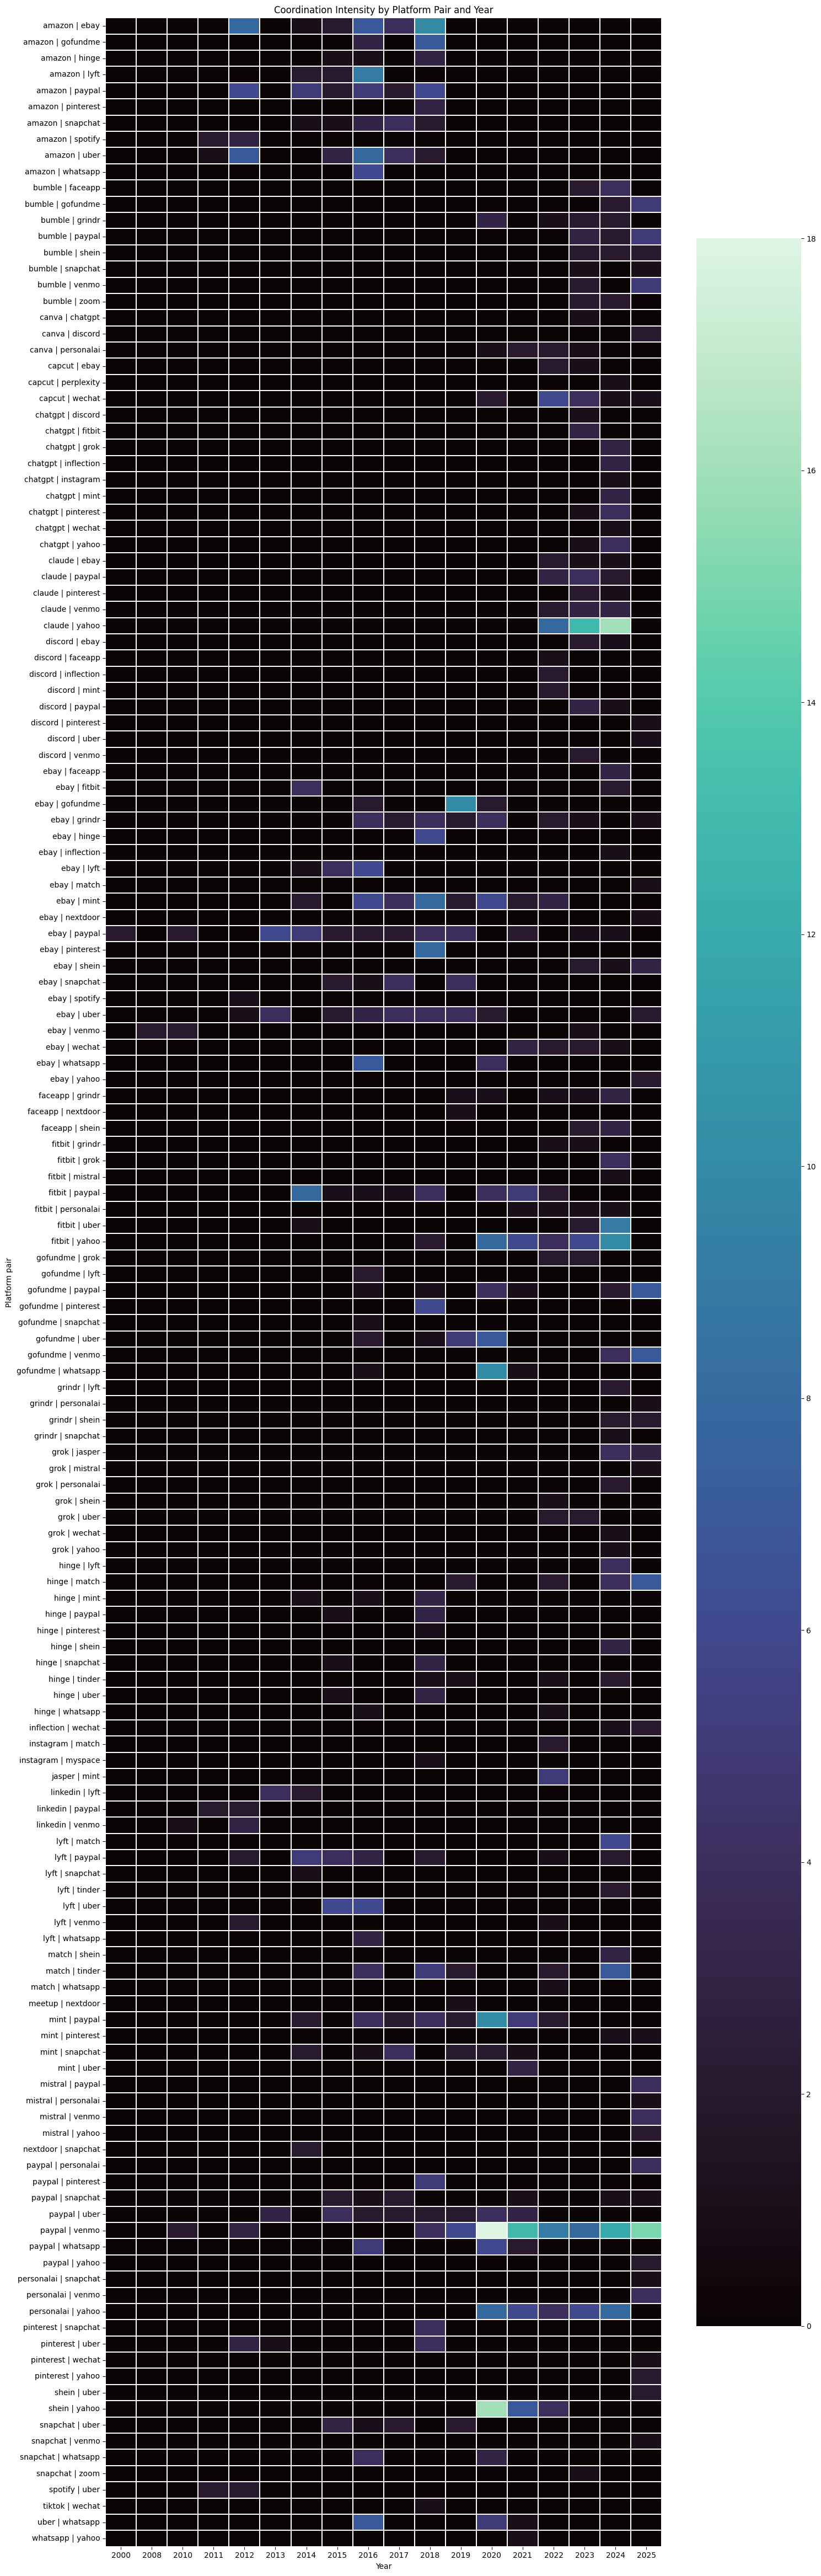

/Users/kasparbeelen/anaconda3/envs/tou/lib/python3.10/site-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):
/Users/kasparbeelen/anaconda3/envs/tou/lib/python3.10/site-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):


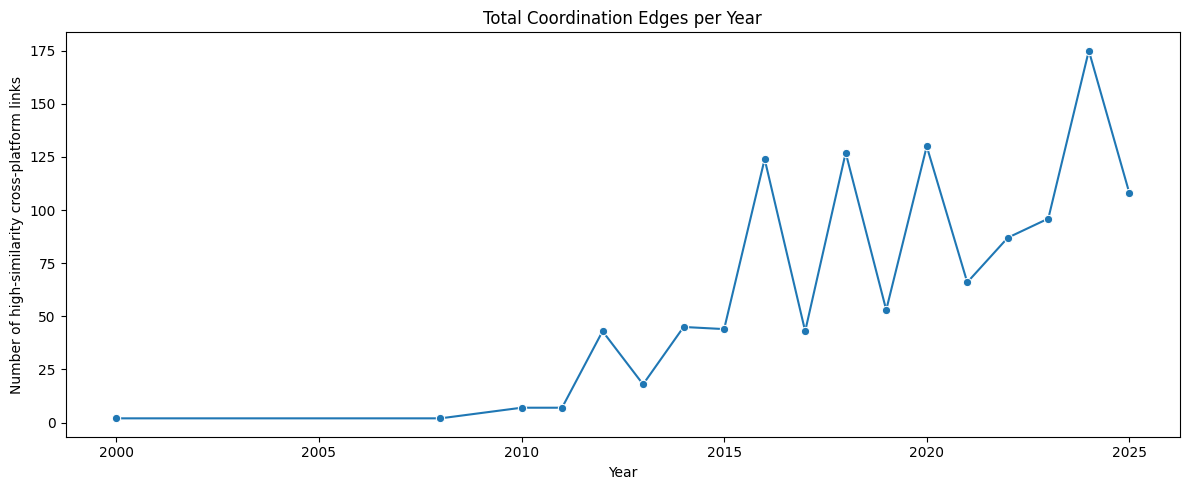

In [30]:
# Visualization B: coordination between platform pairs over time
if coord_edges_df.empty:
    print('No coordination edges to plot.')
else:
    pair_year = (
        coord_edges_df
        .assign(mid_year=((coord_edges_df['u_year'] + coord_edges_df['v_year']) / 2).round().astype(int))
        .groupby(['platform_pair', 'mid_year'])
        .size()
        .rename('n_edges')
        .reset_index()
    )

    pivot_pair_year = pair_year.pivot(index='platform_pair', columns='mid_year', values='n_edges').fillna(0)

    plt.figure(figsize=(15, max(6, 0.30 * len(pivot_pair_year))))
    sns.heatmap(pivot_pair_year, cmap='mako', linewidths=0.1)
    plt.title('Coordination Intensity by Platform Pair and Year')
    plt.xlabel('Year')
    plt.ylabel('Platform pair')
    plt.tight_layout()
    plt.show()

    yearly_coord = pair_year.groupby('mid_year', as_index=False)['n_edges'].sum().sort_values('mid_year')
    plt.figure(figsize=(12, 5))
    sns.lineplot(data=yearly_coord, x='mid_year', y='n_edges', marker='o')
    plt.title('Total Coordination Edges per Year')
    plt.xlabel('Year')
    plt.ylabel('Number of high-similarity cross-platform links')
    plt.tight_layout()
    plt.show()

In [ ]:
# # Optional compact influence-network view
# if G_infl.number_of_edges() == 0:
#     print('Influence graph has no edges at current threshold.')
# else:
#     largest_nodes = max(nx.weakly_connected_components(G_infl), key=len)
#     H = G_infl.subgraph(largest_nodes).copy()

#     plt.figure(figsize=(12, 10))
#     pos = nx.spring_layout(H, seed=42, k=1.1 / np.sqrt(max(1, H.number_of_nodes())))

#     platforms = sorted({H.nodes[n]['platform'] for n in H.nodes})
#     palette = sns.color_palette('tab20', n_colors=max(3, len(platforms)))
#     color_map = {p: palette[i % len(palette)] for i, p in enumerate(platforms)}
#     node_colors = [color_map[H.nodes[n]['platform']] for n in H.nodes]

#     nx.draw_networkx_edges(H, pos, alpha=0.16, arrows=True, arrowstyle='-|>', width=0.7)
#     nx.draw_networkx_nodes(H, pos, node_size=35, node_color=node_colors, alpha=0.9)
#     plt.title('Temporal Influence Network (Largest Weakly Connected Component)')
#     plt.axis('off')
#     plt.tight_layout()
#     plt.show()

# # Inspect strongest influence edges
# if not influence_edges_df.empty:
#     display(
#         influence_edges_df
#         .sort_values(['similarity', 'lag_years'], ascending=[False, True])
#         .head(30)
#     )

In [ ]:
# Optional: sentence-level adoption snapshots for the top influential sources
if influence_scores['influence_score'].max() == 0:
    print('No influential sources under current settings.')
else:
    top_nodes = influence_scores.sort_values('influence_score', ascending=False).head(10)['node_id'].tolist()

    adoption_rows = []
    for n in top_nodes:
        outgoing = influence_edges_df[influence_edges_df['source'] == n]
        if outgoing.empty:
            continue
        adoption_rows.append({
            'node_id': int(n),
            'source_platform': nodes_df.loc[n, 'platform'],
            'source_year': int(nodes_df.loc[n, 'year']),
            'n_adoptions': len(outgoing),
            'mean_similarity': outgoing['similarity'].mean(),
            'median_lag_years': outgoing['lag_years'].median(),
            'source_sentence': nodes_df.loc[n, 'sentence'][:220],
        })

    adoption_df = pd.DataFrame(adoption_rows).sort_values('n_adoptions', ascending=False)
    display(adoption_df)

In [ ]:
from tools.influence_analysis_helpers import visualize_platform_adoption

# Example: visualize adoption patterns for top platforms
top_platforms = platform_influence.head(5)['platform'].tolist()

for platform in top_platforms:
    fig = visualize_platform_adoption(platform, influence_edges_df, nodes_df, min_similarity=0.88)
    if fig:
        fig.show()

In [ ]:
from ipywidgets import Dropdown, FloatSlider, Output, VBox
import plotly.graph_objects as go

# Create interactive selector for exploring any platform
available_platforms = sorted(influence_edges_df['source_platform'].unique().tolist())

platform_dropdown = Dropdown(
    options=available_platforms,
    value=available_platforms[0],
    description='Select Platform:',
    style={'description_width': '120px'}
)

similarity_slider = FloatSlider(
    value=0.88,
    min=0.80,
    max=0.99,
    step=0.01,
    description='Min Similarity:',
    style={'description_width': '120px'}
)

output = Output()

def update_viz(platform, min_sim):
    with output:
        output.clear_output(wait=True)
        fig = visualize_platform_adoption(platform, influence_edges_df, nodes_df, min_similarity=min_sim)
        if fig:
            fig.show()

def on_change(change):
    update_viz(platform_dropdown.value, similarity_slider.value)

platform_dropdown.observe(on_change, names='value')
similarity_slider.observe(on_change, names='value')

# Display controls
controls = VBox([platform_dropdown, similarity_slider])
display(controls)
display(output)

# Show initial plot
update_viz(platform_dropdown.value, similarity_slider.value)


In [ ]:
from tools.influence_analysis_helpers import visualize_sentence_causal_timeline

# Create interactive output
from ipywidgets import interactive, IntSlider, FloatSlider

# Get top influential sentence IDs
top_ids = influence_scores.nlargest(1000, 'influence_score')['node_id'].values

sentence_idx_s = IntSlider(value=int(top_ids[0]), min=0, max=len(nodes_df)-1, step=1, description='Sentence:', layout={'width': '700px'})
min_sim_val = FloatSlider(value=0.80, min=0.50, max=0.99, step=0.01, description='Min Sim:', layout={'width': '400px'})

def show_timeline(sent_idx, min_sim):
    row = nodes_df.iloc[sent_idx]
    infl_score = influence_scores.iloc[sent_idx]['influence_score']
    
    print(f"\n{'='*100}")
    print(f"ROOT SENTENCE: {row['platform'].upper()} ({int(row['year'])}) | Influence Score: {infl_score:.2f}")
    print(f"{'='*100}")
    print(f"{row['sentence'][:400]}{'...' if len(row['sentence']) > 400 else ''}\n")
    
    fig, res = visualize_sentence_causal_timeline(
        sent_idx,
        nodes_df,
        emb_norm,
        influence_edges_df,
        min_similarity=min_sim,
    )
    if fig:
        print(f"Found {len(res)} causally valid adoptions with similarity >= {min_sim:.2f}\n")
        fig.show()
    else:
        print(f"No causally valid adoptions found with similarity >= {min_sim:.2f}\n")

interactive_plot = interactive(show_timeline, sent_idx=sentence_idx_s, min_sim=min_sim_val)
display(interactive_plot)